# AR(1) vs HMM-AR(1) Prediction Performance

This notebook investigates when an HMM-AR(1) model outperforms a single AR(1) model in one-step-ahead predictions, based on simulated data. We vary the "stickiness" of states (probability of staying in the current state), the difference in AR coefficients (β), and sample size (T). Performance is evaluated using out-of-sample RMSE on predictions.

## Key Concepts
- **Stickiness**: Controlled by the diagonal of the transition matrix P (p_stay = p11 = p22).
- **Parameter Difference**: β2 - β1.
- **Evaluation**: Compare RMSE for single AR(1) vs. HMM on holdout data.
- **Predictions**:
  - Single AR(1): y_{t+1} = ρ * y_t
  - HMM: E[y_{t+1} | data] = sum_k α_t[k] * β_k * y_t

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from methods.hmm_ar_1_k_states import (
    simulate_rs_ar1,
    fit_model
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import plotly.express as px

## Helper Functions

We define functions to fit a single AR(1) model, compute predictions, and calculate RMSE.

In [2]:
def fit_single_ar1(y_train):
    X = y_train[:-1].reshape(-1, 1)
    y = y_train[1:]
    model = LinearRegression().fit(X, y)
    return model.coef_[0]


def predict_single_ar1(rho, y_test):
    return rho * y_test[:-1]


def predict_hmm_ar1(params_hat, y_test):
    if params_hat is None or params_hat.get('beta') is None:
        raise ValueError("params_hat is empty or invalid; ensure fit_model_robust returned a valid fit")

    from methods.hmm_ar_1_k_states import forward_algorithm
    alpha, _, _ = forward_algorithm(y_test[:-1], params_hat['beta'], params_hat['sigma'], params_hat['P'])
    filtered_beta = np.dot(alpha, params_hat['beta'])
    return filtered_beta * y_test[:-1]


def compute_rmse(true, pred):
    return np.sqrt(mean_squared_error(true, pred))


def fit_model_robust(y, K, true_beta=None, true_sigma=None, true_P=None, n_starts=10):
    best_loglik = -np.inf
    best_result = None
    best_params = None

    for start in range(n_starts):
        if K == 2 and true_beta is not None:
            beta0 = np.log((1 + true_beta) / (1 - true_beta)) + np.random.normal(scale=0.1, size=2)
            sigma0 = np.log(true_sigma) + np.random.normal(scale=0.1, size=2)
            P0 = np.log(true_P + 1e-8) + np.random.normal(scale=0.1, size=(2, 2))
        else:
            beta0 = np.random.uniform(-0.9, 0.9, size=K)
            sigma0 = np.random.normal(size=K)
            P0 = np.random.normal(size=(K, K))

        result, params_hat = fit_model(y, beta0, sigma0, P0)
        if not result.success or np.isnan(result.fun):
            continue

        loglik = -result.fun
        if np.isnan(loglik):
            continue

        if loglik > best_loglik:
            best_loglik = loglik
            best_result = result
            best_params = params_hat

    if best_params is None:
        raise RuntimeError("fit_model_robust could not find a valid fit; try increasing n_starts or checking data")

    n_params = 2 * K + K * (K - 1)
    n = len(y)
    aic = -2 * best_loglik + 2 * n_params
    bic = -2*best_loglik + np.log(n)*n_params

    return {
        "K": K,
        "loglik": best_loglik,
        "AIC": aic,
        "BIC": bic,
        "result": best_result,
        "params": best_params
    }


## Experiment: Vary Stickiness, Difference, and Sample Size

We simulate data with varying p_stay (stickiness), β difference, and T. For each combination, fit models on 80% training data and evaluate RMSE on 20% test data.

One Beta is fixed.

In [3]:
# Parameters
p_stay_vals = np.array([0.6, 0.8, 0.9, 0.95, 0.98])
diff_vals = np.array([0.1, 0.3, 0.5, 0.7])
T_vals = [300, 500, 1000, 2000]
n_rep = 5
sigma = np.array([0.5, 1.0])

results = []

for p_stay in p_stay_vals:
    P = np.array([[p_stay, 1-p_stay], [1-p_stay, p_stay]])
    print(f"Processing p_stay={p_stay:.2f}")

    for diff in diff_vals:
        beta = np.array([0.2, 0.2 + diff])

        for T in T_vals:
            for rep in range(n_rep):
                # Simulate
                y, _ = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=rep*100 + int(p_stay*100))
                
                # Split
                split = int(0.8 * T)
                y_train, y_test = y[:split], y[split:]
                
                # Single AR(1)
                rho = fit_single_ar1(y_train)
                preds_single = predict_single_ar1(rho, y_test)
                rmse_single = compute_rmse(y_test[1:], preds_single)
                
                # HMM
                try:
                    robust_res = fit_model_robust(y_train, 2, beta, sigma, P, n_starts=10)
                    params_hat = robust_res['params']
                    preds_hmm = predict_hmm_ar1(params_hat, y_test)
                    rmse_hmm = compute_rmse(y_test[1:], preds_hmm)
                except Exception as e:
                    print('HMM fit error:', e)
                    rmse_hmm = np.nan

                results.append({
                    'p_stay': p_stay,
                    'diff': diff,
                    'T': T,
                    'rep': rep,
                    'rmse_single': rmse_single,
                    'rmse_hmm': rmse_hmm,
                    'rmse_diff': rmse_single - rmse_hmm
                })

df = pd.DataFrame(results)
df_agg = df.groupby(['p_stay', 'diff', 'T']).agg({'rmse_diff': 'mean'}).reset_index()

Processing p_stay=0.60
Processing p_stay=0.80
Processing p_stay=0.90
Processing p_stay=0.95
Processing p_stay=0.98


## Visualizations

Heatmaps show the average RMSE difference (HMM - Single AR(1)). Positive values indicate HMM performs better.

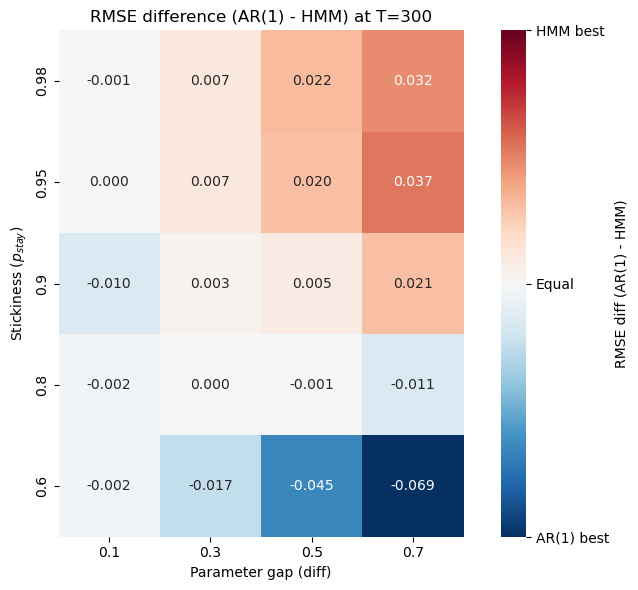

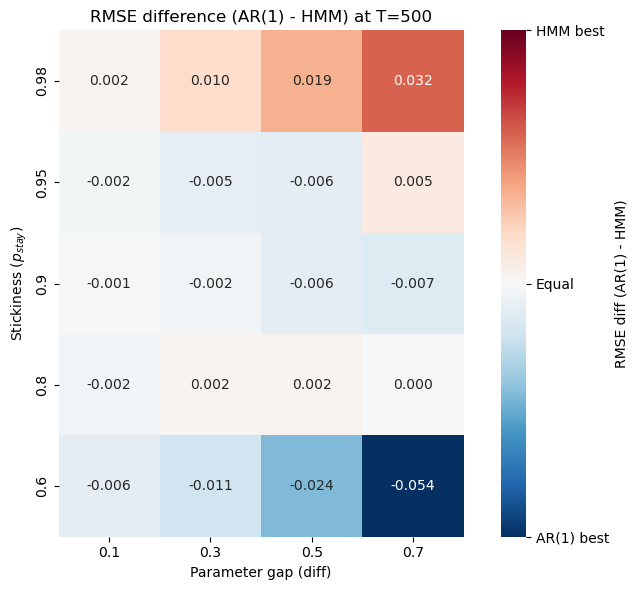

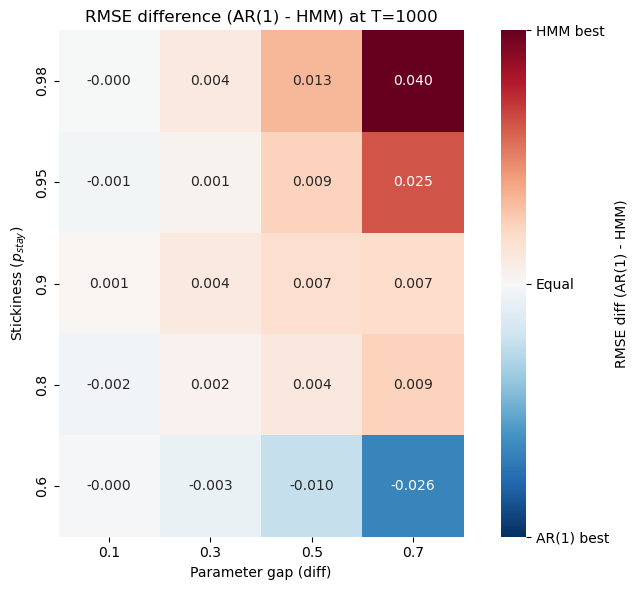

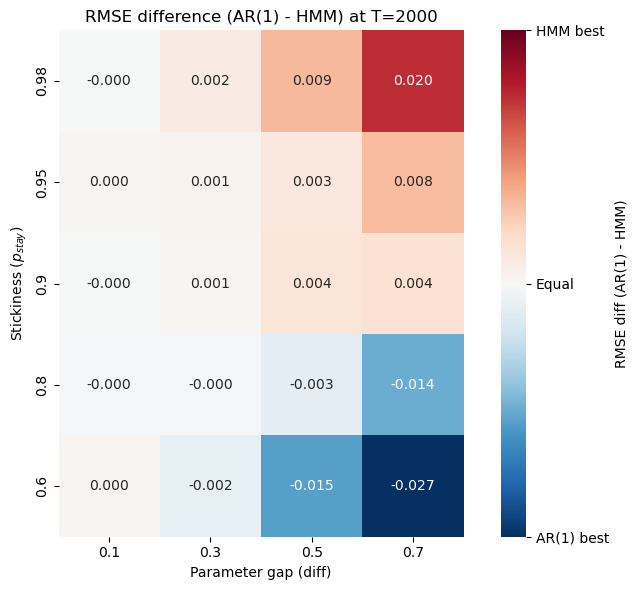

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for T in T_vals:
    sub_df = df_agg[df_agg["T"] == T].pivot(
        index="p_stay", columns="diff", values="rmse_diff"
    ).sort_index(ascending=False)

    max_abs = np.nanmax(np.abs(sub_df.values))

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        sub_df,
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
        center=0,
        annot=True,
        fmt=".3f",
        square=True,
        cbar_kws={
            "label": "RMSE diff (AR(1) - HMM)",
            "ticks": [-max_abs, 0, max_abs]
        }
    )

    cbar = ax.collections[0].colorbar
    cbar.set_ticklabels(["AR(1) best", "Equal", "HMM best"])

    ax.set_title(f"RMSE difference (AR(1) - HMM) at T={T}")
    ax.set_xlabel("Parameter gap (diff)")
    ax.set_ylabel("Stickiness ($p_{stay}$)")

    plt.tight_layout()
    plt.show()


## Conclusion

The heatmaps reveal that HMM outperforms single AR(1) when states are sticky (high p_stay), parameters differ significantly, and sample size is large. This aligns with theory: HMM captures regime shifts better under these conditions.